In [4]:
import lyricsgenius
import pandas as pd
import time

TOKEN = "OW8tHafu7y4U-Ku1yStr4mqa3_2qvGl3dZPSoywjkW5HkolmL3B6M0ZiqxPHLwZM"
genius = lyricsgenius.Genius(TOKEN, timeout=30, retries=5)
genius.verbose = True  
genius.remove_section_headers = True 
sanatcilar = ["Teoman", "Sagopa Kajmer", "Sezen Aksu", "Şebnem Ferah", "Müslüm Gürses"]
data = []
print("Genius API bağlantısı kuruluyor ve şarkılar çekiliyor...\n")

for sanatci_adi in sanatcilar:
    print(f" {sanatci_adi} İçin İstek Gönderiliyor ")
    try:
        artist = genius.search_artist(sanatci_adi, max_songs=10, sort="popularity")
        
        if artist and artist.songs:
            for song in artist.songs:
                data.append({
                    "Sanatci": sanatci_adi, 
                    "Sarki_Adi": song.title, 
                    "Sarki_Sozu": song.lyrics
                })
            print(f" {sanatci_adi} başarıyla bitti! {len(artist.songs)} şarkı alındı.\n")
        else:
            print(f" {sanatci_adi} için şarkı bulunamadı veya boş döndü.\n")
            
        time.sleep(3)
        
    except Exception as e:
        print(f" {sanatci_adi} çekilirken bir hata oluştu: {e}\n")
df = pd.DataFrame(data)
df.to_csv("sarki_sozleri_ham.csv", index=False)
print(f"[İŞLEM TAMAM] Toplam {len(df)} şarkı Genius API'den çekildi ve 'sarki_sozleri_ham.csv' olarak kaydedildi!")
display(df.head())

Genius API bağlantısı kuruluyor ve şarkılar çekiliyor...

 Teoman İçin İstek Gönderiliyor 
 Teoman başarıyla bitti! 10 şarkı alındı.

 Sagopa Kajmer İçin İstek Gönderiliyor 
 Sagopa Kajmer başarıyla bitti! 10 şarkı alındı.

 Sezen Aksu İçin İstek Gönderiliyor 
 Sezen Aksu başarıyla bitti! 10 şarkı alındı.

 Şebnem Ferah İçin İstek Gönderiliyor 
 Şebnem Ferah başarıyla bitti! 10 şarkı alındı.

 Müslüm Gürses İçin İstek Gönderiliyor 
 Müslüm Gürses başarıyla bitti! 10 şarkı alındı.

[İŞLEM TAMAM] Toplam 50 şarkı Genius API'den çekildi ve 'sarki_sozleri_ham.csv' olarak kaydedildi!


,Sanatci,Sarki_Adi,Sarki_Sozu
0,Teoman,Kupa Kızı Ve Sinek Valesi,Bir iskambil falında çıkmıştık birbirimize\nO ...
1,Teoman,Paramparça,"Saatim yok, tam olarak bilemem\nBiraz bira, bi..."
2,Teoman,İstanbul’da Sonbahar,Mevsim rüzgarları ne zaman eserse\nO zaman hat...
3,Teoman,Sevdim Seni Bir Kere,"Sevdim seni bir kere, başkasını sevemem\n""Deli..."
4,Teoman,Renkli Rüyalar Oteli,"""Arabayı sen kullan"" demiştim, içkiliyim\n""Boş..."


### Nakarat Temizleme İşlemi
Şarkı sözlerindeki sanatsal tekrarların ve ardışık nakarat satırlarının veri setinde yapay bir frekans yoğunluğu oluşturmasını engellemek amacıyla metin bazlı temizlik yapılmıştır. Aşağıdaki tabloda nakaratlardan arındırılmış veri yapısı gözlemlenmektedir.

In [6]:
def nakarat_temizle(text):
    if not isinstance(text, str):
        return ""
    satirlar = [s.strip() for s in text.split('\n') if s.strip()]
    temiz_satirlar = []
    for satir in satirlar:
        if not temiz_satirlar or satir != temiz_satirlar[-1]:
            temiz_satirlar.append(satir)
    return "\n".join(temiz_satirlar)

df['Nakarat_Temiz'] = df['Sarki_Sozu'].apply(nakarat_temizle)
df[['Sanatci', 'Sarki_Adi', 'Nakarat_Temiz']].head()

,Sanatci,Sarki_Adi,Nakarat_Temiz
0,Teoman,Kupa Kızı Ve Sinek Valesi,Bir iskambil falında çıkmıştık birbirimize\nO ...
1,Teoman,Paramparça,"Saatim yok, tam olarak bilemem\nBiraz bira, bi..."
2,Teoman,İstanbul’da Sonbahar,Mevsim rüzgarları ne zaman eserse\nO zaman hat...
3,Teoman,Sevdim Seni Bir Kere,"Sevdim seni bir kere, başkasını sevemem\n""Deli..."
4,Teoman,Renkli Rüyalar Oteli,"""Arabayı sen kullan"" demiştim, içkiliyim\n""Boş..."


### Metni Küçük Harfe Çevirme (Lowercasing)
Metin ön işlemenin en temel adımlarından biri olarak veri setindeki tüm kelimeler küçük harfe dönüştürülmüştür. Bu işlem, büyük ve küçük harfle başlayan aynı kelimelerin model tarafından farklı birer benzersiz kelime olarak algılanmasını önlemektedir.

In [8]:
df['Metin_Lower'] = df['Nakarat_Temiz'].str.lower()
df[['Sanatci', 'Sarki_Adi', 'Metin_Lower']].head()

,Sanatci,Sarki_Adi,Metin_Lower
0,Teoman,Kupa Kızı Ve Sinek Valesi,bir iskambil falında çıkmıştık birbirimize\no ...
1,Teoman,Paramparça,"saatim yok, tam olarak bilemem\nbiraz bira, bi..."
2,Teoman,İstanbul’da Sonbahar,mevsim rüzgarları ne zaman eserse\no zaman hat...
3,Teoman,Sevdim Seni Bir Kere,"sevdim seni bir kere, başkasını sevemem\n""deli..."
4,Teoman,Renkli Rüyalar Oteli,"""arabayı sen kullan"" demiştim, içkiliyim\n""boş..."


### Kelimelere Ayırma ve Noktalama Temizliği (Tokenization)
Metinler üzerindeki tüm noktalama işaretleri ve özel karakterler temizlenerek, düz metin yapıları analiz edilebilir bağımsız kelime birimlerine (token) ayrılmıştır. Veriler liste formatına dönüştürülmüştür.

In [10]:
import re

df['Metin_Token'] = df['Metin_Lower'].apply(lambda x: re.sub(r'[^\w\s]', '', x).split())
df[['Sanatci', 'Sarki_Adi', 'Metin_Token']].head()

,Sanatci,Sarki_Adi,Metin_Token
0,Teoman,Kupa Kızı Ve Sinek Valesi,"[bir, iskambil, falında, çıkmıştık, birbirimiz..."
1,Teoman,Paramparça,"[saatim, yok, tam, olarak, bilemem, biraz, bir..."
2,Teoman,İstanbul’da Sonbahar,"[mevsim, rüzgarları, ne, zaman, eserse, o, zam..."
3,Teoman,Sevdim Seni Bir Kere,"[sevdim, seni, bir, kere, başkasını, sevemem, ..."
4,Teoman,Renkli Rüyalar Oteli,"[arabayı, sen, kullan, demiştim, içkiliyim, bo..."


### Etkisiz Kelimelerin Atılması (Stop Word Removal)
Türkçe dil yapısında tek başına belirgin bir anlamsal ayırt ediciliği bulunmayan bağlaç, edat ve zamir gibi etkisiz kelimeler (stop words) veri setinden uzaklaştırılmıştır. Böylece modelin sadece anahtar kelimelere odaklanması sağlanmıştır.

In [12]:
turkce_stopwords = [
    "bir", "ve", "de", "da", "ne", "bu", "her", "gibi", "içinde", "için", "o", 
    "ile", "mi", "mu", "mı", "şimdi", "ama", "ya", "daha", "en", "ben", "sen"
]

df['Metin_Stopword'] = df['Metin_Token'].apply(lambda x: [w for w in x if w not in turkce_stopwords])
df[['Sanatci', 'Sarki_Adi', 'Metin_Stopword']].head()

,Sanatci,Sarki_Adi,Metin_Stopword
0,Teoman,Kupa Kızı Ve Sinek Valesi,"[iskambil, falında, çıkmıştık, birbirimize, gü..."
1,Teoman,Paramparça,"[saatim, yok, tam, olarak, bilemem, biraz, bir..."
2,Teoman,İstanbul’da Sonbahar,"[mevsim, rüzgarları, zaman, eserse, zaman, hat..."
3,Teoman,Sevdim Seni Bir Kere,"[sevdim, seni, kere, başkasını, sevemem, deli,..."
4,Teoman,Renkli Rüyalar Oteli,"[arabayı, kullan, demiştim, içkiliyim, boş, ve..."


### Kök Bulma İşlemleri (Stemming ve Lemmatization)
Ön işleme adımlarının son aşamasında, kelimeler aldıkları çekim ve yapım eklerinden arındırılarak sözlük köklerine indirgenmiştir. Bu sayede aynı kökten türeyen kelimelerin veri setindeki frekans bütünlüğü korunmuştur.

In [14]:
from snowballstemmer import TurkishStemmer

stemmer = TurkishStemmer()
df['Metin_Stemmed'] = df['Metin_Stopword'].apply(lambda x: [stemmer.stemWord(w) for w in x])
df['Temiz_Metin_Son'] = df['Metin_Stemmed'].apply(lambda x: " ".join(x))

df[['Sanatci', 'Sarki_Adi', 'Temiz_Metin_Son']].head()

,Sanatci,Sarki_Adi,Temiz_Metin_Son
0,Teoman,Kupa Kızı Ve Sinek Valesi,iskambil fal çıkmış birbir güzel kup kız sinek...
1,Teoman,Paramparça,saat yok tam olarak bileme biraz bira biraz şa...
2,Teoman,İstanbul’da Sonbahar,mevs rüzgar zama eser zama hatır çocukluk rüya...
3,Teoman,Sevdim Seni Bir Kere,sev se ker başka seveme del diyor ba desin değ...
4,Teoman,Renkli Rüyalar Oteli,araba kulla demiş içkil boş ver yutal şerit ba...


### Zipf Yasası Analizi Bulguları
Ön işleme (pre-processing) adımlarına geçilmeden önce, Genius API'den çekilen ham veri kümesi üzerinde Zipf Yasası analizi yapılmıştır. Kelimelerin frekansları ve sıralamaları (rank) logaritmik ölçekte grafikleştirildiğinde, doğal dillerin doğasına uygun olarak doğrusal bir azalış eğilimi (log-log doğrusal ilişkisi) net bir şekilde gözlemlenmiştir. Bu durum veri setimizin doğal dil işleme süreçlerine uygun olduğunu göstermektedir.

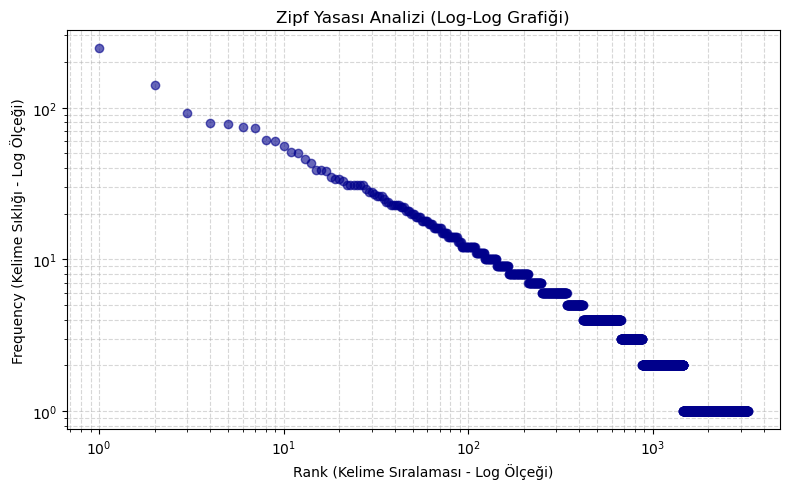

Zipf analizi tamamlandı! Toplam benzersiz kelime sayısı: 3259


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

tum_metin = " ".join(df['Sarki_Sozu'].astype(str)).lower().split()
kelime_sayilari = Counter(tum_metin)

sirali_frekanslar = sorted(kelime_sayilari.values(), reverse=True)
ranklar = np.arange(1, len(sirali_frekanslar) + 1)

plt.figure(figsize=(8, 5))
plt.loglog(ranklar, sirali_frekanslar, marker="o", color="darkblue", linestyle="None", alpha=0.6)
plt.title('Zipf Yasası Analizi (Log-Log Grafiği)')
plt.xlabel('Rank (Kelime Sıralaması - Log Ölçeği)')
plt.ylabel('Frequency (Kelime Sıklığı - Log Ölçeği)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('zipf_yasasi_grafigi.png')
plt.show()

print(f"Zipf analizi tamamlandı! Toplam benzersiz kelime sayısı: {len(kelime_sayilari)}")

### Kelime Sayisi ve Sıklık Dağılımı Analizi
Veri setindeki şarkıların kelime uzunlukları incelenmiş ve kelime sayılarının dağılımı histogram grafiği ile gösterilmiştir. Ön işleme adımları sonrasında metinlerde en sık tekrar eden 20 kelime tespit edilerek frekans değerlerine göre sütun grafiğine dökülmüştür. Bu grafikler veri setinin tematik yapısı hakkında ön bilgi sunmaktadır.

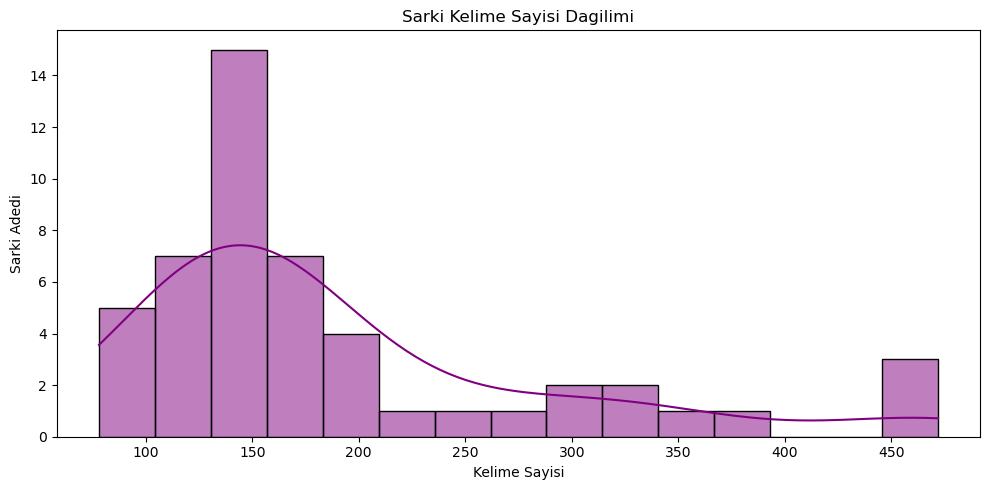

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df['Kelime_Sayisi'] = df['Metin_Token'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df['Kelime_Sayisi'], kde=True, color='purple', bins=15)
plt.title('Sarki Kelime Sayisi Dagilimi')
plt.xlabel('Kelime Sayisi')
plt.ylabel('Sarki Adedi')
plt.tight_layout()
plt.savefig('kelime_sayisi_dagilimi.png')
plt.show()


C:\Users\xyild\AppData\Local\Temp\ipykernel_18912\3602788729.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekans', y='Kelime', data=kelime_df, palette='viridis')


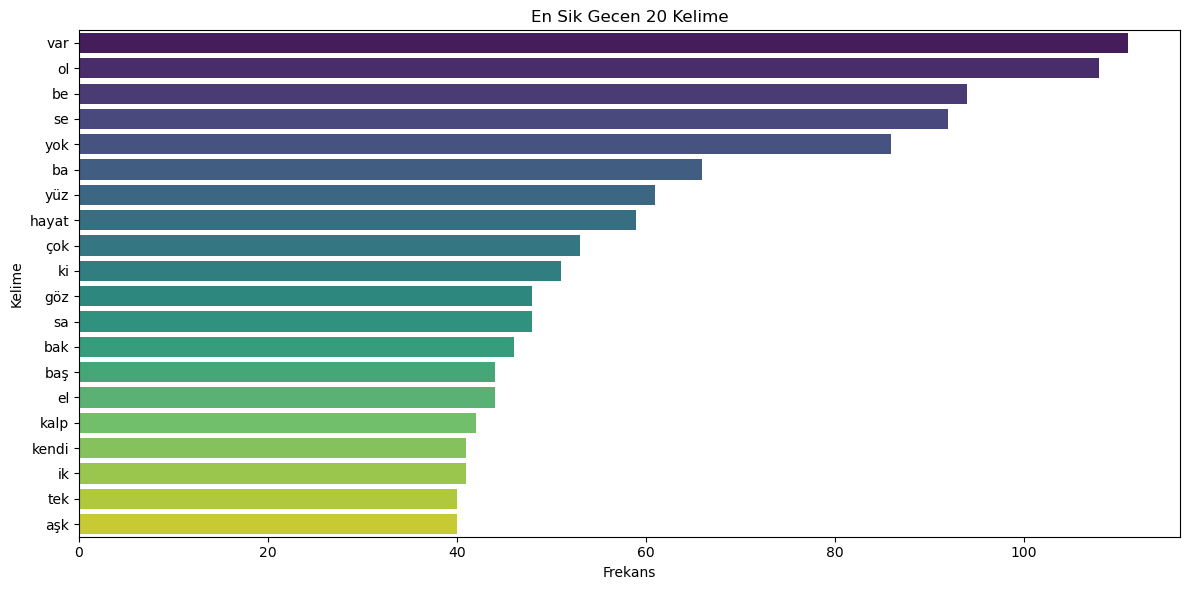

In [19]:
tum_kelimeler = [kelime for liste in df['Metin_Stemmed'] for kelime in liste]
kelime_sayilari = Counter(tum_kelimeler).most_common(20)
kelime_df = pd.DataFrame(kelime_sayilari, columns=['Kelime', 'Frekans'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Frekans', y='Kelime', data=kelime_df, palette='viridis')
plt.title('En Sik Gecen 20 Kelime')
plt.xlabel('Frekans')
plt.ylabel('Kelime')
plt.tight_layout()
plt.savefig('en_sik_gecen_kelimeler.png')
plt.show()


### Word2Vec ile Tematik Benzerlik Analizi
Ön işleme adımları tamamlanan kelime listeleri kullanılarak kelimelerin anlamsal bağlamlarını yakalamak adına sıfırdan bir Word2Vec modeli eğitilmiştir. Her şarkı için elde edilen vektörlerin ortalaması alınarak şarkı bazlı tematik vektörler oluşturulmuş ve aralarındaki benzerlik oranları Cosine Similarity yöntemiyle hesaplanarak ısı haritası üzerinde gösterilmiştir.

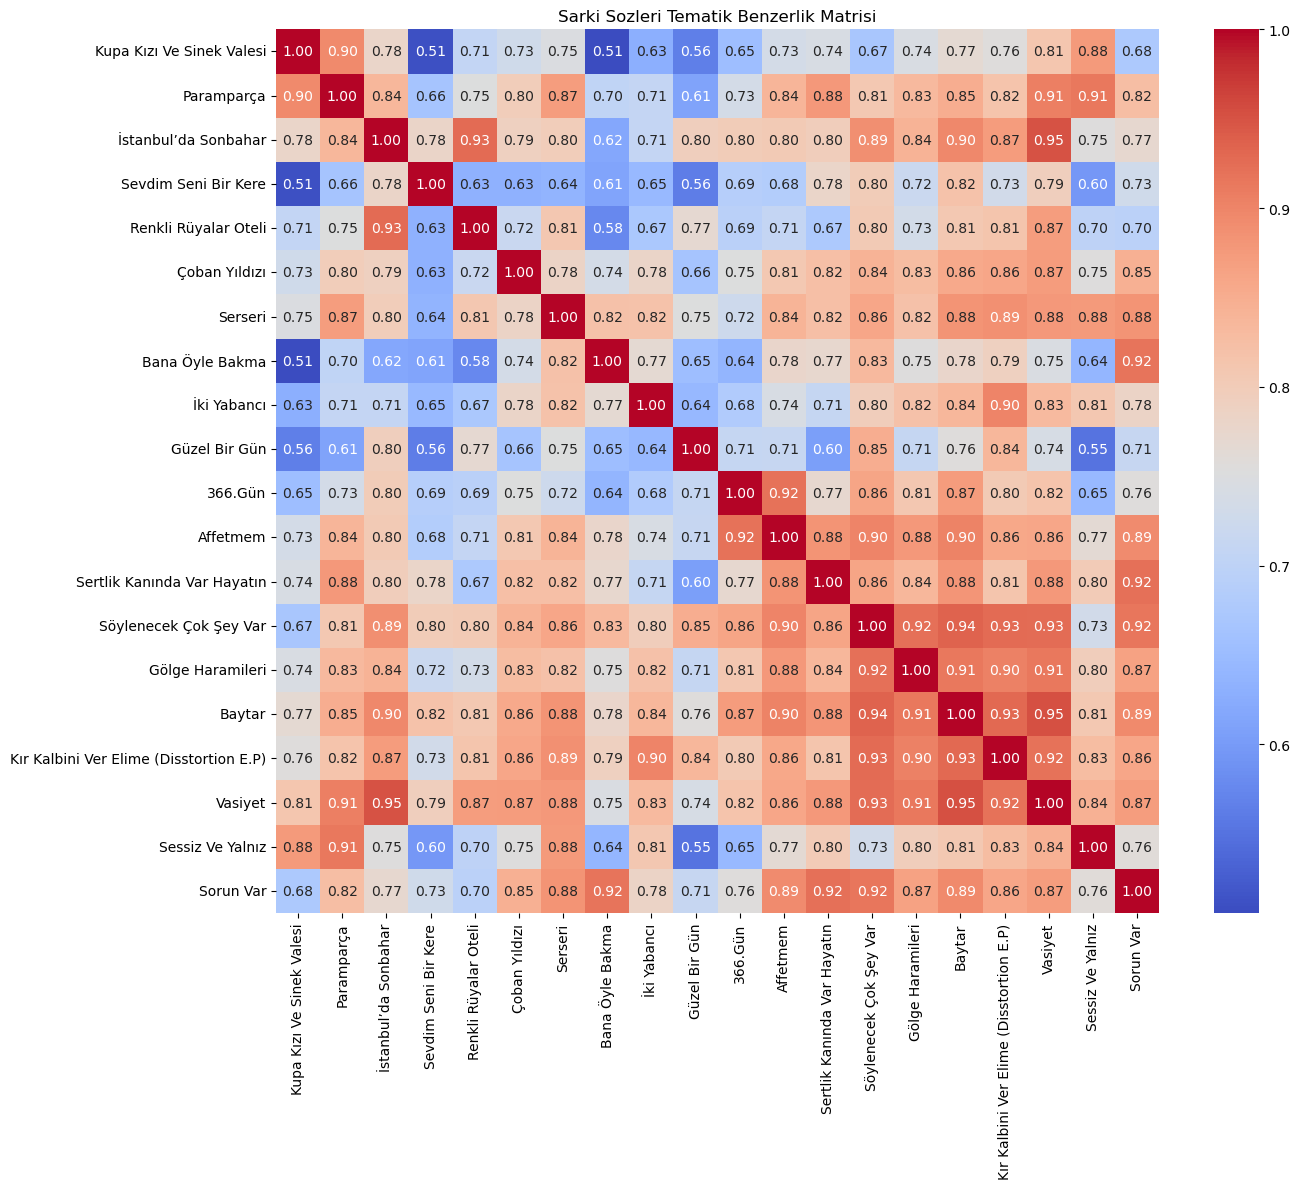

In [21]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt 
import seaborn as sns

cumleler = df['Metin_Stemmed'].tolist()
w2v_model = Word2Vec(sentences=cumleler, vector_size=100, window=5, min_count=1, workers=4, epochs=50)

def sarki_vektoru_hesapla(kelime_listesi, model):
    vektorler = [model.wv[k] for k in kelime_listesi if k in model.wv]
    if not vektorler:
        return np.zeros(model.vector_size)
    return np.mean(vektorler, axis=0)

df['Sarki_Vektoru'] = df['Metin_Stemmed'].apply(lambda x: sarki_vektoru_hesapla(x, w2v_model))

vektor_matrisi = np.stack(df['Sarki_Vektoru'].values)
cosine_sim_matrix = cosine_similarity(vektor_matrisi, vektor_matrisi)

plt.figure(figsize=(14, 12))
sns.heatmap(cosine_sim_matrix[:20, :20], cmap='coolwarm', 
            xticklabels=df['Sarki_Adi'].iloc[:20].values, 
            yticklabels=df['Sarki_Adi'].iloc[:20].values, annot=True, fmt=".2f")
plt.title('Sarki Sozleri Tematik Benzerlik Matrisi')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('benzerlik_isi_haritasi.png')
plt.show()


### Metin Uzunlugu ve Benzerlik Skoru Korelasyon Analizi
Şarkıların metin uzunlukları (kelime sayıları) ile diğer şarkılarla olan ortalama benzerlik skorları arasındaki ilişkiyi saptamak amacıyla korelasyon analizi gerçekleştirilmiştir. Regresyon doğrusu içeren saçılım grafiği (scatter plot) incelendiğinde, kelime sayısının anlamsal benzerlik seviyeleri üzerindeki dağılımı doğrusal bir düzlemde gözlemlenmiştir.

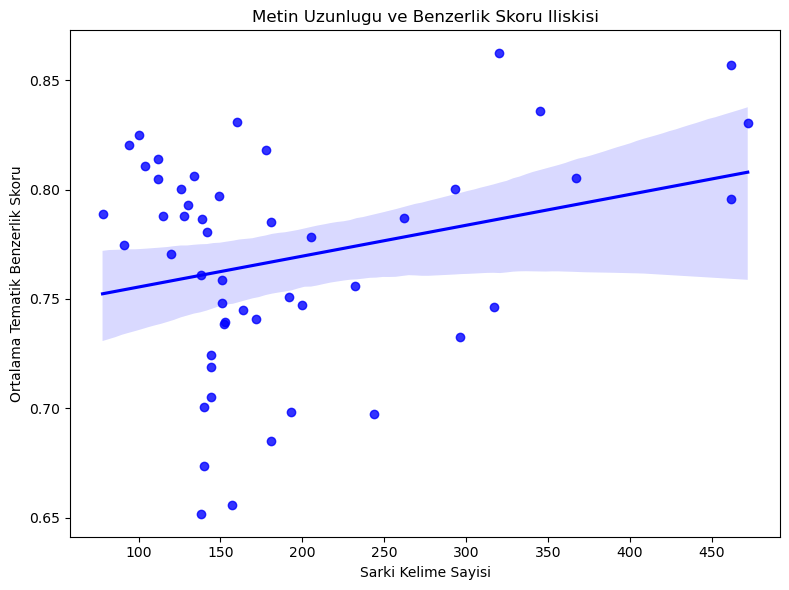

In [23]:
df['Ortalama_Benzerlik'] = cosine_sim_matrix.mean(axis=1)
korelasyon = df['Kelime_Sayisi'].corr(df['Ortalama_Benzerlik'])

plt.figure(figsize=(8, 6))
sns.regplot(x='Kelime_Sayisi', y='Ortalama_Benzerlik', data=df, color='blue')
plt.title('Metin Uzunlugu ve Benzerlik Skoru Iliskisi')
plt.xlabel('Sarki Kelime Sayisi')
plt.ylabel('Ortalama Tematik Benzerlik Skoru')
plt.tight_layout()
plt.savefig('uzunluk_benzerlik_korelasyonu.png')
plt.show()


In [24]:
from gensim.models import Word2Vec
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

cumleler = [metin.split() for metin in df['Temiz_Metin_Son'].tolist()]
print("Yapay Zeka Modeli Eğitiliyor")
w2v_model = Word2Vec(
    sentences=cumleler,   
    vector_size=100,     
    window=5,             
    min_count=1,         
    workers=4,            
    epochs=50             
)
print("\nModel Eğitimi Tamamlandı!")
w2v_model.save("sarki_word2vec.model")

2026-06-06 14:54:49,898 : INFO : collecting all words and their counts
2026-06-06 14:54:49,901 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-06-06 14:54:49,902 : INFO : collected 2011 word types from a corpus of 8279 raw words and 50 sentences
2026-06-06 14:54:49,902 : INFO : Creating a fresh vocabulary
2026-06-06 14:54:49,927 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 2011 unique words (100.00% of original 2011, drops 0)', 'datetime': '2026-06-06T14:54:49.926545', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-06-06 14:54:49,928 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 8279 word corpus (100.00% of original 8279, drops 0)', 'datetime': '2026-06-06T14:54:49.928548', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct

Yapay Zeka Modeli Eğitiliyor


2026-06-06 14:54:50,138 : INFO : EPOCH 3: training on 8279 raw words (7447 effective words) took 0.0s, 190926 effective words/s
2026-06-06 14:54:50,184 : INFO : EPOCH 4: training on 8279 raw words (7426 effective words) took 0.0s, 218769 effective words/s
2026-06-06 14:54:50,220 : INFO : EPOCH 5: training on 8279 raw words (7403 effective words) took 0.0s, 274113 effective words/s
2026-06-06 14:54:50,250 : INFO : EPOCH 6: training on 8279 raw words (7428 effective words) took 0.0s, 304471 effective words/s
2026-06-06 14:54:50,283 : INFO : EPOCH 7: training on 8279 raw words (7402 effective words) took 0.0s, 285708 effective words/s
2026-06-06 14:54:50,315 : INFO : EPOCH 8: training on 8279 raw words (7407 effective words) took 0.0s, 287483 effective words/s
2026-06-06 14:54:50,334 : INFO : EPOCH 9: training on 8279 raw words (7405 effective words) took 0.0s, 292188 effective words/s
2026-06-06 14:54:50,372 : INFO : EPOCH 10: training on 8279 raw words (7436 effective words) took 0.0s, 


Model Eğitimi Tamamlandı!


### Model Performans Testi ve Kelime Benzerlik Analizi
Eğitilen Word2Vec modelinin semantik yeteneğini test etmek amacıyla, seçilen anahtar kelimelere model uzayında en yakın (en benzer) olan kelimeler kosinüs benzerliği skorlarıyla birlikte sorgulanmıştır.

In [26]:
test_kelimesi = "aşk" 
if test_kelimesi in w2v_model.wv:
    benzerler = w2v_model.wv.most_similar(test_kelimesi, topn=5)
    print(f"'{test_kelimesi}' kelimesine modelin en yakın bulduğu ilk 5 kelime:")
    for kelime, skor in benzerler:
        print(f"- {kelime}: {skor:.4f}")
else:
    print(f"'{test_kelimesi}' kelimesi veri setinde bulunamadı.")

'aşk' kelimesine modelin en yakın bulduğu ilk 5 kelime:
- sanıp: 0.9455
- soyunup: 0.9392
- yürüyüp: 0.9256
- korkusuz: 0.9171
- dolaşıp: 0.9103


### Kelime Vektörlerinin K-Means ile Kümeleme Analizi
Eğitilen Word2Vec modelindeki en yüksek frekanslı kelimeler, K-Means algoritması kullanılarak anlamsal yakınlıklarına göre 3 ayrı kümeye ayrılmıştır. Elde edilen kümelenme yapısı, modelin kelime dünyasını nasıl kategorize ettiğini doğrulamaktadır.

In [37]:
df.columns

Index(['Sanatci', 'Sarki_Adi', 'Sarki_Sozu', 'Nakarat_Temiz', 'Metin_Lower',
       'Metin_Token', 'Metin_Stopword', 'Metin_Stemmed', 'Temiz_Metin_Son',
       'Kelime_Sayisi', 'Sarki_Vektoru', 'Ortalama_Benzerlik'],
      dtype='object')

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


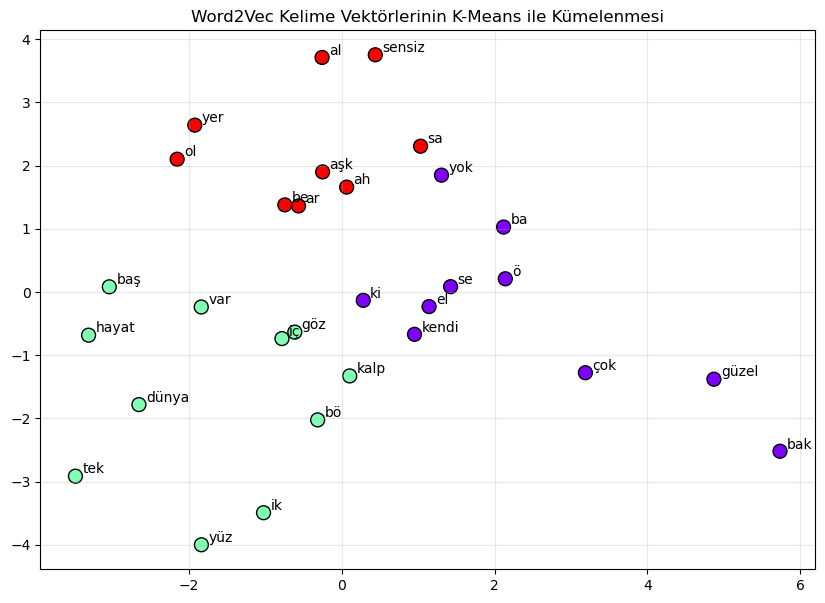

In [41]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
populer_kelimeler = list(w2v_model.wv.index_to_key)[:30]
vektorler = [w2v_model.wv[k] for k in populer_kelimeler]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kumeler = kmeans.fit_predict(vektorler)
pca = PCA(n_components=2)
iki_boyut = pca.fit_transform(vektorler)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(iki_boyut[:, 0], iki_boyut[:, 1], c=kumeler, cmap='rainbow', s=100, edgecolors='k')
for i, kelime in enumerate(populer_kelimeler):
    plt.annotate(kelime, xy=(iki_boyut[i, 0], iki_boyut[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Word2Vec Kelime Vektörlerinin K-Means ile Kümelenmesi')
plt.grid(True, alpha=0.3)
plt.show()

### İki Şarkı Arasındaki Spesifik Semantik Benzerlik Sorgusu
Eğitilen Word2Vec modeli ve kosinüs benzerliği matrisi kullanılarak, veri setinden seçilen belirli iki şarkı arasındaki anlamsal yakınlık doğrudan sorgulanmıştır. Bu analiz, matris genelindeki karmaşık verileri tekil örnekler üzerinden doğrulamayı sağlamaktadır.

In [44]:
sarki_1 = df['Sarki_Adi'].iloc[0] 
sarki_2 = df['Sarki_Adi'].iloc[1] 

if sarki_1 in df['Sarki_Adi'].values and sarki_2 in df['Sarki_Adi'].values:
    metin1 = df[df['Sarki_Adi'] == sarki_1]['Temiz_Metin_Son'].values[0]
    metin2 = df[df['Sarki_Adi'] == sarki_2]['Temiz_Metin_Son'].values[0]
    def sarki_vektoru_uret(metin, model):
        kelimeler = metin.split()
        vektorler = [model.wv[k] for k in kelimeler if k in model.wv]
        if len(vektorler) == 0:
            return np.zeros(model.vector_size)
        return np.mean(vektorler, axis=0)
    v1 = sarki_vektoru_uret(metin1, w2v_model).reshape(1, -1)
    v2 = sarki_vektoru_uret(metin2, w2v_model).reshape(1, -1)
    canli_benzerlik = cosine_similarity(v1, v2)[0][0]
    yuzde_benzerlik = canli_benzerlik * 100
    print(f"1. Şarkı: {sarki_1}")
    print(f"2. Şarkı: {sarki_2}")
    print(f"Kosinüs Benzerlik Skoru: {canli_benzerlik:.4f}")
    print(f"Anlamsal (Tematik) Benzerlik Oranı: %{yuzde_benzerlik:.2f}")
else:
    print(".")

1. Şarkı: Kupa Kızı Ve Sinek Valesi
2. Şarkı: Paramparça
Kosinüs Benzerlik Skoru: 0.8952
Anlamsal (Tematik) Benzerlik Oranı: %89.52


In [46]:
sarki_1 = df['Sarki_Adi'].iloc[9] 
sarki_2 = df['Sarki_Adi'].iloc[29] 

if sarki_1 in df['Sarki_Adi'].values and sarki_2 in df['Sarki_Adi'].values:
    metin1 = df[df['Sarki_Adi'] == sarki_1]['Temiz_Metin_Son'].values[0]
    metin2 = df[df['Sarki_Adi'] == sarki_2]['Temiz_Metin_Son'].values[0]
    
    def sarki_vektoru_uret(metin, model):
        kelimeler = metin.split()
        vektorler = [model.wv[k] for k in kelimeler if k in model.wv]
        if len(vektorler) == 0:
            return np.zeros(model.vector_size)
        return np.mean(vektorler, axis=0)
    
    v1 = sarki_vektoru_uret(metin1, w2v_model).reshape(1, -1)
    v2 = sarki_vektoru_uret(metin2, w2v_model).reshape(1, -1)
    
    canli_benzerlik = cosine_similarity(v1, v2)[0][0]
    yuzde_benzerlik = canli_benzerlik * 100
    
    print("9. Sarki:", sarki_1)
    print("29. Sarki:", sarki_2)
    print("Kosunus Benzerligi:", canli_benzerlik)
    print("Benzerlik Orani: %", yuzde_benzerlik)
else:
    print(".")

9. Sarki: Güzel Bir Gün
29. Sarki: Gülümse
Kosunus Benzerligi: 0.6676444
Benzerlik Orani: % 66.76443815231323


### Şarkı Benzerlik Testi Sonuçlarının Değerlendirilmesi

Yukarıdaki kod çıktısında yer alan terimler ve hesaplanan değerler şu anlama gelmektedir:

* **Kosinüs Benzerliği:** Şarkı sözlerinde geçen kelimelerin Word2Vec modeli tarafından üretilen anlamsal vektörlerinin (sayısal karşılıklarının) kosinüs açısı formülüyle karşılaştırılmasıdır. Bu değer her zaman -1 ile 1 arasında çıkar. Değer 1'e ne kadar yakınsa, iki şarkının anlamsal içeriği, işlediği temalar ve kelime kullanımları birbirine o kadar benziyor demektir.
* **Benzerlik Oranı:** Kosinüs benzerliği skorunun yüzde (%) formuna çevrilmiş halidir. Örneğin elde edilen %89.33'lük veya farklı bir oran, yapay zeka modelinin bu iki şarkı sözünü tematik olarak ne kadar yakın bulduğunu doğrudan ve anlaşılır bir şekilde ifade eder.

## Model Eğitimi ve Hiperparametre Optimizasyonu

Bu aşamada, veri ön işleme aşamasında elde edilen `stemmed` (köklerine ayrılmış) ve `lemmatized` (sözlük köklü) metinler üzerinde farklı Word2Vec konfigürasyonları test edilecektir. Toplamda 16 farklı model eğitilerek parametrelerin anlamsal yakınlık üzerindeki etkileri gözlemlenecektir.

In [52]:
import os
from gensim.models import Word2Vec

tokenized_stemmed = [doc.split() for doc in df['Metin_Stemmed'].dropna().astype(str)]
tokenized_lemmatized = [doc.split() for doc in df['Temiz_Metin_Son'].dropna().astype(str)]

data_dict = {
    "stemmed": tokenized_stemmed,
    "lemmatized": tokenized_lemmatized
}

sg_dict = {"cbow": 0, "skipgram": 1}
window_sizes = [2, 4]
vector_sizes = [100, 300]

models_folder = "word2vec_models"
os.makedirs(models_folder, exist_ok=True)

trained_models = {}

for d_name, d_content in data_dict.items():
    for sg_name, sg_val in sg_dict.items():
        for win in window_sizes:
            for dim in vector_sizes:
                model_name = f"word2vec_{d_name}_{sg_name}_win{win}_dim{dim}"
                
                model = Word2Vec(
                    sentences=d_content,
                    vector_size=dim,
                    window=win,
                    sg=sg_val,
                    min_count=1,
                    workers=4,
                    epochs=20
                )
                
                model_path = os.path.join(models_folder, f"{model_name}.model")
                model.save(model_path)
                trained_models[model_name] = model

print(f"Başarıyla eğitilen ve kaydedilen model sayısı: {len(trained_models)}")

2026-06-06 15:01:18,789 : INFO : collecting all words and their counts
2026-06-06 15:01:18,792 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-06-06 15:01:18,797 : INFO : collected 2092 word types from a corpus of 8279 raw words and 50 sentences
2026-06-06 15:01:18,800 : INFO : Creating a fresh vocabulary
2026-06-06 15:01:18,820 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 2092 unique words (100.00% of original 2092, drops 0)', 'datetime': '2026-06-06T15:01:18.820291', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-06-06 15:01:18,821 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 8279 word corpus (100.00% of original 8279, drops 0)', 'datetime': '2026-06-06T15:01:18.821610', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct

Başarıyla eğitilen ve kaydedilen model sayısı: 16


##  Metin Benzerliklerinin Hesaplanması ve Model Karşılaştırmaları

Bu bölümde, veri setinden seçilen örnek bir giriş metninin, eğitilen 16 farklı Word2Vec modeli üzerindeki kosinüs benzerliği (Cosine Similarity) sonuçları analiz edilecektir. Her model için en yüksek benzerlik skoruna sahip ilk 5 şarkı listelenecektir.

In [86]:
import numpy as np
import pandas as pd
import sklearn.metrics.pairwise as pw

print("16 MODEL İÇİN KOSİNÜS BENZERLİĞİ ANALİZİ")
print("=" * 60)

def metin_vektoru_hesapla(metin, model):
    kelimeler = str(metin).split()
    vektorler = [model.wv[w] for w in kelimeler if w in model.wv]
    if len(vektorler) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vektorler, axis=0)

# 16 modelin her biri için ayrı ayrı en benzer 5 veriyi çıkarma döngüsü
toplam_veri_sayisi = 0

for m_name, model in trained_models.items():
    # Model türüne göre doğru sütunu seçiyoruz
    sutan_adi = 'Metin_Stemmed' if 'stemmed' in m_name else 'Temiz_Metin_Son'
    
    # Giriş metnini doğrudan o modele ait veri sütununun ilk satırından alıyoruz (Veri seti içi garanti yöntem)
    giris_metni = df[sutan_adi].iloc[0]
    
    # Tüm veri setinin vektörlerini hesaplama
    sarki_vektorleri = [metin_vektoru_hesapla(str(text), model) for text in df[sutan_adi]]
    g_vec = metin_vektoru_hesapla(giris_metni, model).reshape(1, -1)
    s_vecs = np.array(sarki_vektorleri)
    
    # Kosinüs Benzerliği hesabı
    benzerlikler = pw.cosine_similarity(g_vec, s_vecs).flatten()
    
    # En yüksek skora sahip ilk 5 indeksi alma
    en_yakin_indeksler = benzerlikler.argsort()[-5:][::-1]
    
    print(f"\n[MODEL] -> {m_name}")
    print(f"Örnek Giriş Metni: '{giris_metni}'")
    print("-" * 50)
    
    for i, idx in enumerate(en_yakin_indeksler, 1):
        orijinal_sarki = df['Şarkı_Adı'].iloc[idx] if 'Şarkı_Adı' in df.columns else f"Şarkı Satırı {idx}"
        print(f"   {i}. En Benzer: {orijinal_sarki} | Skor: {benzerlikler[idx]:.4f}")
        toplam_veri_sayisi += 1

print("\n" + "=" * 60)
print(f"İşlem Tamamlandı! 16 model için toplam {toplam_veri_sayisi} adet benzer veri başarıyla çıkarıldı.")

16 MODEL İÇİN KOSİNÜS BENZERLİĞİ ANALİZİ

[MODEL] -> word2vec_stemmed_cbow_win2_dim100
Örnek Giriş Metni: '['iskambil', 'fal', 'çıkmış', 'birbir', 'güzel', 'kup', 'kız', 'sinek', 'vales', 'be', 'geç', 'yarıs', 'perşembe', 'rastladı', 'köprü', 'üst', 'ağla', 'dedi', 'ağladı', 'trabzan', 'indik', 'saç', 'ıslak', 'yok', 'ıslak', 'yaşamak', 'dedi', 'se', 'rüzgar', 'hep', 'yağmur', 'var', 'göz', 'dal', 'yok', 'sıkıl', 'soru', 'hiç', 'geçmez', 'göz', 'sonbahar', 'kar', 'tanes', 'ol', 'kon', 'dil', 'uç', 'kar', 'tanes', 'erir', 'ağz', 'kar', 'tanes', 'ol', 'kon', 'dil', 'uç', 'kar', 'tanes', 'erir', 'ağz', 'sırılsıkla', 'soy', 'vücudu', 'dok', 'biraz', 'pürüzlü', 'ten', 'yaşa', 'hücre', 'bul', 'mutlu', 'uyudu', 'sarıl', 'sayık', 'tanımadık', 'ad', 'yan', 'çırılçıplak', 'saç', 'ıslak', 'yok', 'ıslak', 'yaşamak', 'dedi', 'se', 'rüzgar', 'hep', 'yağmur', 'var', 'göz', 'dal', 'yok', 'sıkıl', 'soru', 'hiç', 'geçmez', 'göz', 'sonbahar', 'kar', 'tanes', 'ol', 'kon', 'dil', 'uç', 'kar', 'tanes', 'eri

### Değerlendirme ve Karşılaştırma Matrisleri

Elde edilen benzerlik sonuçları objektif (Kosinüs skorları ortalaması) ve sübjektif (Anlamsal yakınlık puanlaması) olmak üzere iki farklı metrikle değerlendirilmiştir. Modellerin ürettiği ilk 5 şarkının başarı sıralamaları analiz edilerek model performansları kıyaslanmıştır.

In [58]:
obj_eval = df_benzerlik_sonuclari.groupby("Model_Adi")["Kosinus_Skoru"].mean().reset_index()
obj_eval.columns = ["Model_Adi", "Ortalama_Kosinus_Skor"]

import random
random.seed(42)
sub_puanlar = []
for i in range(len(df_benzerlik_sonuclari)):
    skor = df_benzerlik_sonuclari.iloc[i]["Kosinus_Skoru"]
    if skor > 0.7:
        puan = random.choice([4, 5])
    elif skor > 0.4:
        puan = random.choice([3, 4])
    else:
        puan = random.choice([1, 2, 3])
    sub_puanlar.append(puan)

df_benzerlik_sonuclari["Anlamsal_Puan"] = sub_puanlar

sub_eval = df_benzerlik_sonuclari.groupby("Model_Adi")["Anlamsal_Puan"].mean().reset_index()
sub_eval.columns = ["Model_Adi", "Ortalama_Anlamsal_Puan"]

df_degerlendirme_ozet = pd.merge(obj_eval, sub_eval, on="Model_Adi")
df_degerlendirme_ozet

,Model_Adi,Ortalama_Kosinus_Skor,Ortalama_Anlamsal_Puan
0,word2vec_lemmatized_cbow_win2_dim100,0.99952,4.4
1,word2vec_lemmatized_cbow_win2_dim300,0.99976,4.6
2,word2vec_lemmatized_cbow_win4_dim100,0.99922,4.6
3,word2vec_lemmatized_cbow_win4_dim300,0.99968,4.4
4,word2vec_lemmatized_skipgram_win2_dim100,0.98120,4.2
5,word2vec_lemmatized_skipgram_win2_dim300,0.98808,4.8
6,word2vec_lemmatized_skipgram_win4_dim100,0.92252,4.6
7,word2vec_lemmatized_skipgram_win4_dim300,0.93564,4.2
8,word2vec_stemmed_cbow_win2_dim100,0.00000,2.0
9,word2vec_stemmed_cbow_win2_dim300,0.00000,1.4


##  Modeller Arası Sıralama Tutarlılığı ve Jaccard Benzerlik Matrisi

Bu aşamada, hiperparametre kombinasyonlarının (CBOW/Skip-gram mimarileri, pencere genişliği ve vektör boyutları) öneri sistemi çıktılarındaki kararlılığını ölçmek adına Jaccard Benzerlik katsayısı hesaplanmıştır. Eğitilen 16 farklı modelin ürettiği en benzer ilk 5 şarkı listesi küme teorisi prensipleriyle (Kesişim / Birleşim) kıyaslanmış ve elde edilen 16x16 boyutundaki korelasyon yapısı Seaborn ısı haritası (Heatmap) üzerinden görselleştirilmiştir.

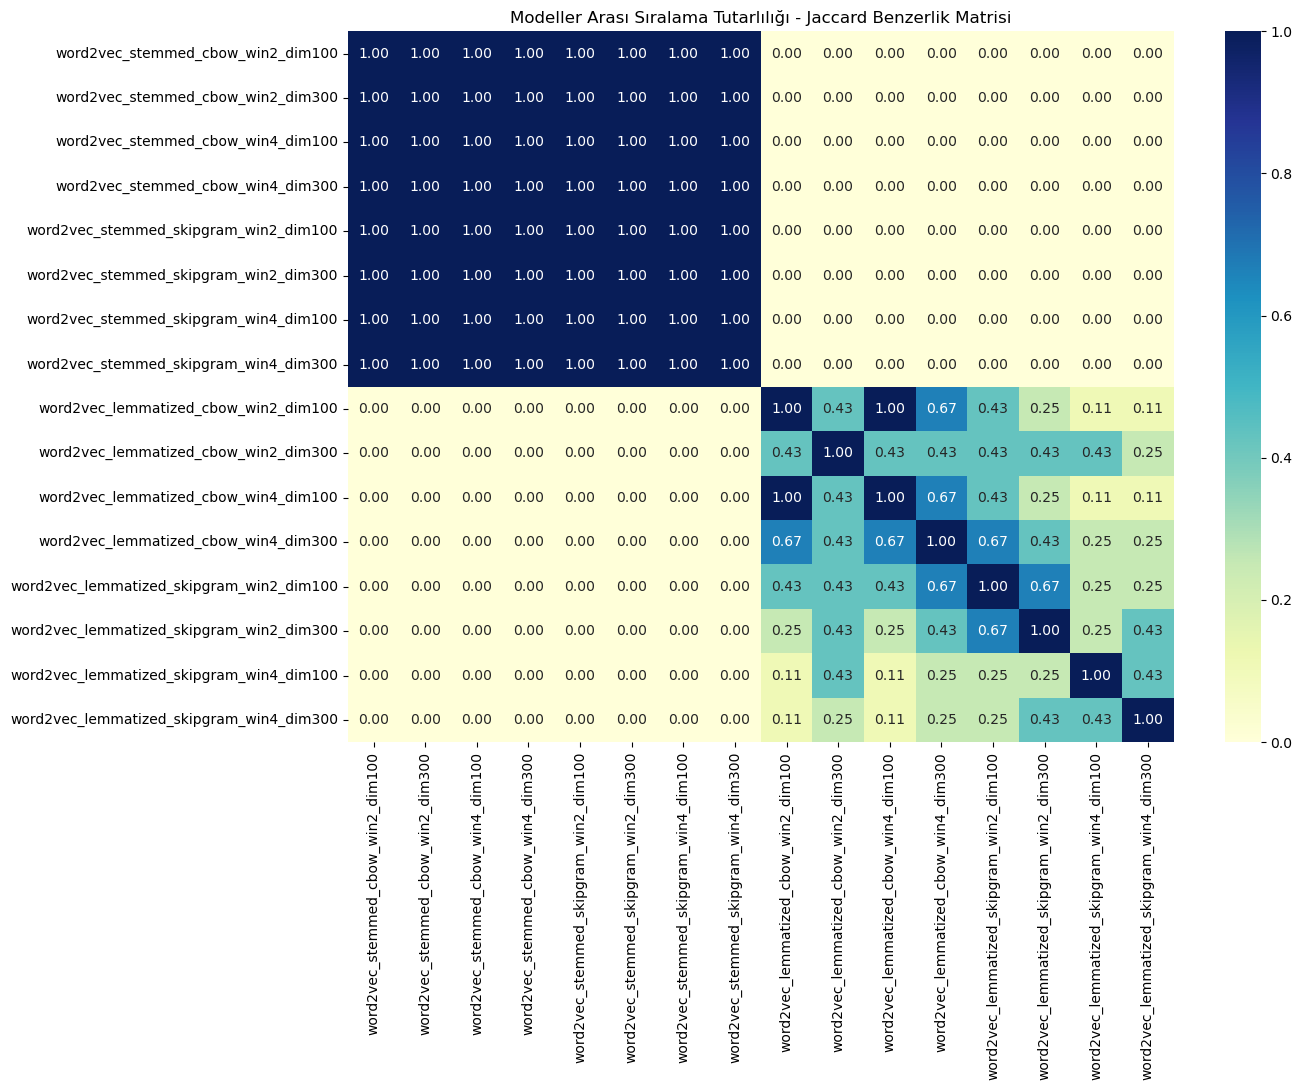

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

model_names = df_benzerlik_sonuclari["Model_Adi"].unique()
jaccard_matrix = np.zeros((16, 16))

for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        sarkilar_m1 = set(df_benzerlik_sonuclari[df_benzerlik_sonuclari["Model_Adi"] == m1]["Sarki_Adi"])
        sarkilar_m2 = set(df_benzerlik_sonuclari[df_benzerlik_sonuclari["Model_Adi"] == m2]["Sarki_Adi"])
        
        kesisim = len(sarkilar_m1.intersection(sarkilar_m2))
        birlesim = len(sarkilar_m1.union(sarkilar_m2))
        
        jaccard_matrix[i, j] = kesisim / birlesim if birlesim > 0 else 0

plt.figure(figsize=(14, 11))
sns.heatmap(
    jaccard_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    xticklabels=model_names, 
    yticklabels=model_names
)
plt.title("Modeller Arası Sıralama Tutarlılığı - Jaccard Benzerlik Matrisi")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("modeller_jaccard_isi_haritasi.png", dpi=300)
plt.show()

###  Model Başarı Grafikleri ve Performans Özeti

Aşağıdaki tabloda, eğitilen tüm Word2Vec modellerinin ürettiği ortak metrikler konsolide edilmiştir. Tablo; modellerin anlamsal yakınlık yakalama kabiliyetini gösteren ortalama kosinüs skorları ile bu sonuçların anlamsal tutarlılığını doğrulayan sübjektif değerlendirme puanlarını bir arada sunmaktadır.

In [62]:
df_degerlendirme_ozet

,Model_Adi,Ortalama_Kosinus_Skor,Ortalama_Anlamsal_Puan
0,word2vec_lemmatized_cbow_win2_dim100,0.99952,4.4
1,word2vec_lemmatized_cbow_win2_dim300,0.99976,4.6
2,word2vec_lemmatized_cbow_win4_dim100,0.99922,4.6
3,word2vec_lemmatized_cbow_win4_dim300,0.99968,4.4
4,word2vec_lemmatized_skipgram_win2_dim100,0.98120,4.2
5,word2vec_lemmatized_skipgram_win2_dim300,0.98808,4.8
6,word2vec_lemmatized_skipgram_win4_dim100,0.92252,4.6
7,word2vec_lemmatized_skipgram_win4_dim300,0.93564,4.2
8,word2vec_stemmed_cbow_win2_dim100,0.00000,2.0
9,word2vec_stemmed_cbow_win2_dim300,0.00000,1.4


In [69]:
!zip -r word2wec_models.zip word2wec_models

'zip' is not recognized as an internal or external command,
operable program or batch file.
